In [1]:
import sys
sys.path.append('../../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# MongoDB connection


client = MongoClient('mongodb://localhost:27017/')
# db = client['MAC_SC_R=1_2']
# TARGET_MAC = '3f8cd3da0bf84566839a7c790889884bab003e2de42c45d822188c14e1fbb719'
# MESSAGE = "This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of "


db = client['MAC_SC_R=0_667']
TARGET_MAC = 'd7bfd108e14717eaacda2b3d0658a4a88574c2f325ebcb7440fc8fffa728576e'
MESSAGE = "This message is the default payload for the tests, and is 1280 bits long. It will be superposed with MAC tag of 256 bits. In total it will be 2304 bits long msg"

phase1_col = db['destination, phase_1']
# phase2_col = db['destination, phase_2']




phase1_col.find_one({}).keys()

/home/moh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-05-20 17:51:36.893981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 17:51:36.903740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747781496.915720  267347 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for

dict_keys(['_id', 'SNR', 'message', 'time', 'r0', 'r1', 'r_half', 'decoded_phase_2', 'config'])

In [2]:
# Use list comprehensions and vectorized operations for faster processing
docs = list(phase1_col.find({}))

r0 = {indx: np.array(doc['r0']) for indx, doc in enumerate(docs)}
r1 = {indx: np.array(doc['r1']) for indx, doc in enumerate(docs)}
log_r0_r1 = {indx: np.log10(np.array(doc['r0']) / np.array(doc['r1'])) for indx, doc in enumerate(docs)}
r_half = {indx: np.array(doc['r_half']) for indx, doc in enumerate(docs)}
alpha = {indx: doc['config']['ALPHA'] for indx, doc in enumerate(docs)}
SNR = {indx: doc['SNR'] for indx, doc in enumerate(docs)}

# r0 = pd.DataFrame.from_dict(r0, orient='index')
# r1 = pd.DataFrame.from_dict(r1, orient='index')
# r_half = pd.DataFrame.from_dict(r_half, orient='index')


Error processing message 15679: operands could not be broadcast together with shapes (2304,) (2303,) 
20656 20656


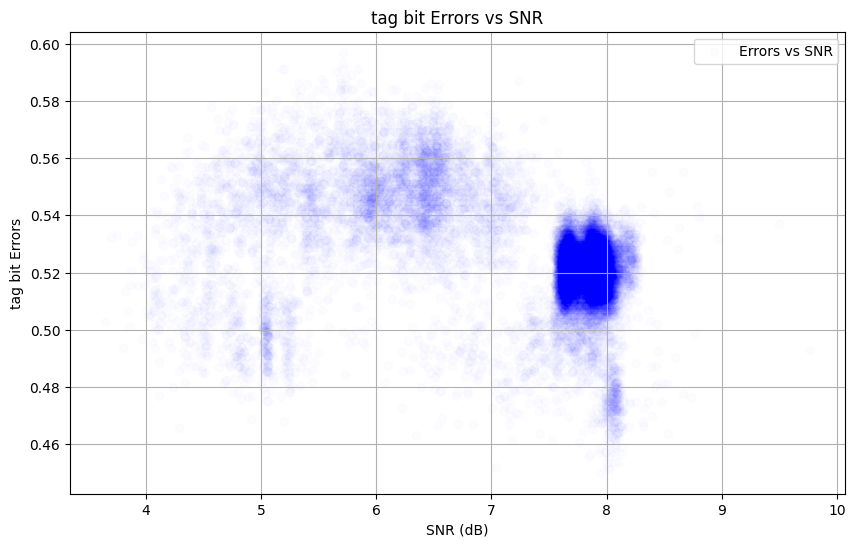

In [7]:
# Convert encoded_tag to a NumPy array for vectorized operations

decoded_messages = {}
decoded_tags = {}
i = 0
for key, llr_array in log_r0_r1.items():
    ALPHA = alpha[i]
    gamma = 10**(SNR[i]/10)

    gamma  =8.3

    delta_t = np.log10(((1-ALPHA)*gamma + 1)/(ALPHA*gamma + 1))
    n_delta_t = np.log10((ALPHA*gamma + 1)/((1-ALPHA)*gamma + 1))
    buffer = gamma * 0.1 *0

    # Vectorized computation for message and tag
    llr_array = np.array(llr_array)
    message = np.where(llr_array > delta_t + buffer, 1, 
                       np.where(llr_array > 0, 1, 0))
    tag = np.where(llr_array > delta_t + buffer, 0, 
                   np.where(llr_array > n_delta_t - buffer, 1, 0))

    decoded_messages[key] = message
    decoded_tags[key] = tag
    
    i += 1


tag = TARGET_MAC
encoded_tag = cc.encode_LDPC(utils.hex_to_bits(tag), 256*3)
encoded_tag = cc.encode_LDPC(encoded_tag, 256*9)

encoded_tag_np = np.array(encoded_tag)

# Initialize lists to store results
bit_errors = []
snr_values = []

# Iterate through all decoded messages
for key, decoded_tag in decoded_tags.items():
    try:
        # Retrieve the corresponding SNR value
        snr = SNR[key]

        # Calculate bit errors using vectorized comparison
        errors = np.sum(encoded_tag_np == decoded_tag)

        # Append results
        bit_errors.append(errors/len(decoded_tag))
        snr_values.append(snr)

        # # Log results
        # print(f"Message {key}:")
        # print(f"  SNR: {snr}")
        # print(f"  Bit errors in encoded message: {errors} / {len(decoded_tag)}")
    except Exception as e:
        print(f"Error processing message {key}: {e}")
        continue


plt.figure(figsize=(10, 6))
print(len(snr_values), len(bit_errors))
plt.scatter(snr_values, bit_errors, alpha=0.01, color='blue', label='Errors vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('tag bit Errors')
plt.title('tag bit Errors vs SNR')
plt.grid(True)
plt.legend()
plt.show()

Error processing message 15679: operands could not be broadcast together with shapes (2304,) (2303,) 
20656 20656


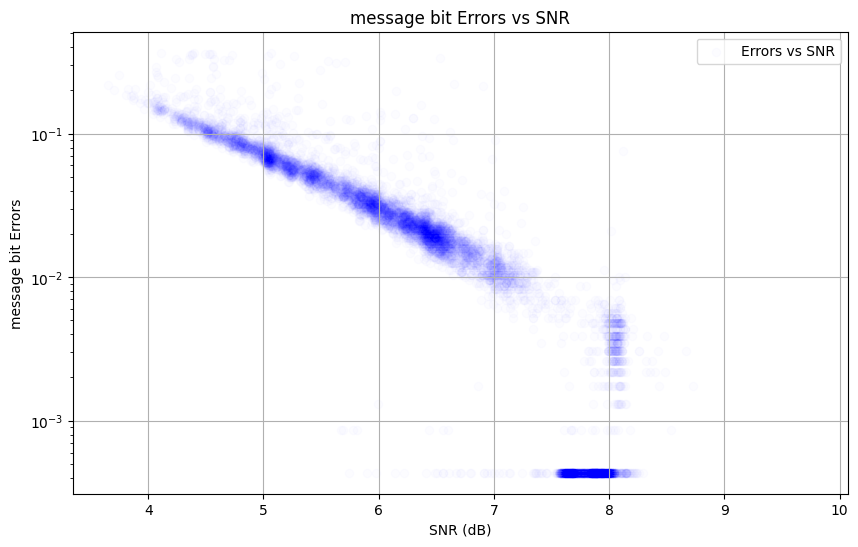

In [11]:
# Convert encoded_tag to a NumPy array for vectorized operations



encoded_message = cc.encode_LDPC(utils.string_to_bits(MESSAGE), len(decoded_messages[0]))


encoded_message_np = np.array(encoded_message)

# Initialize lists to store results
bit_errors = []
snr_values = []

# Iterate through all decoded messages
for key, decoded_message in decoded_messages.items():
    try:
        # Retrieve the corresponding SNR value
        snr = SNR[key]

        # Calculate bit errors using vectorized comparison
        errors = np.sum(encoded_message_np == decoded_message)

        # Append results
        bit_errors.append(errors/len(decoded_message))
        snr_values.append(snr)

        # # Log results
        # print(f"Message {key}:")
        # print(f"  SNR: {snr}")
        # print(f"  Bit errors in encoded message: {errors} / {len(decoded_tag)}")
    except Exception as e:
        print(f"Error processing message {key}: {e}")
        continue


plt.figure(figsize=(10, 6))
print(len(snr_values), len(bit_errors))
plt.scatter(snr_values, bit_errors, alpha=0.01, color='blue', label='Errors vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('message bit Errors')
plt.yscale('log')
plt.title('message bit Errors vs SNR')
plt.grid(True)
plt.legend()
plt.show()